In [2]:

import os

os.chdir(os.path.join(os.getcwd(), '..'))


In [3]:
os.getcwd()

'd:\\learning\\learning\\programing\\portfolio_projects\\1_image'

In [4]:
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
import cv2
from torchvision.transforms import v2
from src.logging import logger
from torchvision import tv_tensors
import torch
from src.constants import *


In [33]:
class MRIDataset2(Dataset):

#?-------------------------maybe it is better to reinit the chousen df ind in the and of the epoch    
    def __init__(self, subset_df_path, empty_img_ratio = 0.2, transform = None, shuffle = False, random_state = 42):
        
        self.subset_df = pd.read_csv(subset_df_path)
        self.empty_ratio = empty_img_ratio
        self.transform = transform
        self.shuffle = shuffle
        self.random_state = random_state

        self.len_pos_empty = len(self) * empty_img_ratio
        self.len_empty = self.subset_df.empty_slice.sum()
        self.remain_pos_empty = self.len_pos_empty
        self.remain_empty = self.len_empty
        self.inc = 0

        self.rng = np.random.default_rng(seed = random_state)


    def __len__(self):

        return (~self.subset_df.empty_slice).sum() // (1 - self.empty_ratio)
         

    def __getitem__(self, index): 

        while self.subset_df.iloc[index + self.inc].empty_slice:

            if (self.empty_ratio > 0) & (self.empty_ratio < 1):
                p = self.remain_pos_empty / self.remain_empty
                approved = self.rng.choice([0,1], p=[1-p, p])
                self.remain_empty -=1

                if approved:
                    self.remain_pos_empty -= 1
                    break

                else:
                    self.inc += 1

            elif self.empty_ratio == 0:
            
                self.inc += 1

            else:

                break


        entry = self.subset_df.iloc[index + self.inc]
    
        img_0 = cv2.imread(entry.prev_path, cv2.IMREAD_UNCHANGED)
        img_1 = cv2.imread(entry.path, cv2.IMREAD_UNCHANGED)
        img_2 = cv2.imread(entry.next_path, cv2.IMREAD_UNCHANGED)

        img = np.stack([img_0, img_1, img_2])
        

        mask = np.load(entry.mask_path)

        return self.transform(img, mask)

    def on_epoch_end(self):

        if self.shuffle:
            self.subset_df.sample(frac = 1, random_state=self.random_state).reset_index(drop = True)

        self.remain_pos_empty = self.len_pos_empty
        self.remain_empty = self.len_empty
        self.inc = 0

In [6]:

df =pd.read_csv('data\\preprocessed_data\\final_data\\train.csv')


In [7]:
df.sample(frac = 1).reset_index(drop = True)

,empty_slice,path,prev_path,next_path,mask_path
0,False,data\extracted_data\train\case125\case125_day0...,data\extracted_data\train\case125\case125_day0...,data\extracted_data\train\case125\case125_day0...,data\preprocessed_data\final_data\output_mask\...
1,False,data\extracted_data\train\case107\case107_day1...,data\extracted_data\train\case107\case107_day1...,data\extracted_data\train\case107\case107_day1...,data\preprocessed_data\final_data\output_mask\...
2,True,data\extracted_data\train\case108\case108_day0...,data\extracted_data\train\case108\case108_day0...,data\extracted_data\train\case108\case108_day0...,data\preprocessed_data\final_data\output_mask\...
3,True,data\extracted_data\train\case6\case6_day0\sca...,data\extracted_data\train\case6\case6_day0\sca...,data\extracted_data\train\case6\case6_day0\sca...,data\preprocessed_data\final_data\output_mask\...
4,True,data\extracted_data\train\case32\case32_day19\...,data\extracted_data\train\case32\case32_day19\...,data\extracted_data\train\case32\case32_day19\...,data\preprocessed_data\final_data\output_mask\...
...,...,...,...,...,...
35179,True,data\extracted_data\train\case154\case154_day1...,data\extracted_data\train\case154\case154_day1...,data\extracted_data\train\case154\case154_day1...,data\preprocessed_data\final_data\output_mask\...
35180,False,data\extracted_data\train\case74\case74_day19\...,data\extracted_data\train\case74\case74_day19\...,data\extracted_data\train\case74\case74_day19\...,data\preprocessed_data\final_data\output_mask\...
35181,True,data\extracted_data\train\case135\case135_day1...,data\extracted_data\train\case135\case135_day1...,data\extracted_data\train\case135\case135_day1...,data\preprocessed_data\final_data\output_mask\...
35182,True,data\extracted_data\train\case113\case113_day1...,data\extracted_data\train\case113\case113_day1...,data\extracted_data\train\case113\case113_day1...,data\preprocessed_data\final_data\output_mask\...


In [21]:
t = v2.ToTensor()
c, b = t([[1,2],[3,4]], [[1,2],[3,4]])

C:\Users\vital\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [7]:
class MRIDataset(Dataset):



    def __init__(self, subset_df_path, empty_img_ratio = 0.2, transform = None, random_state = 42, max_epoch = 200, max_seed = 2000):
        logger.logging.info('entering the creation of dataset')
        subset_df = pd.read_csv(subset_df_path)

        self.not_empty_df = subset_df[~subset_df.empty_slice].drop('empty_slice', axis = 1)
        self.empty_df = subset_df[subset_df.empty_slice].drop('empty_slice', axis = 1)

        self.empty_ratio = empty_img_ratio
        self.transform = transform
        self.random_state = random_state


        rng = np.random.default_rng(seed = random_state)
        
        self.seed_arr = rng.integers(1, max_seed, max_epoch)
        self.idx = 0

        self.orig_rat = len(self.empty_df) / len(subset_df)

        if (self.empty_ratio < self.orig_rat) & (self.empty_ratio > 0):
            self.empty_fract = int(len(self.not_empty_df) / (1 - self.empty_ratio) * self.empty_ratio)
            self.partial_df = self._get_part_df(self.seed_arr[self.idx])
            self.idx = 1
            

        elif self.empty_ratio == 0:
            self.partial_df = self.not_empty_df
            self.empty_fract = 0

        else:
            self.partial_df = subset_df
            self.empty_fract = len(self.empty_df)

        logger.logging.info('dataset successfully created. DO NOT FORGT TO USE ---> on_epoch_end <--- FUNCTION')
          
        

    def _get_part_df(self, random_random_state):
        df = pd.concat(
            [self.not_empty_df, 
             self.empty_df.sample(frac = 1, random_state= random_random_state).iloc[:self.empty_fract]], 
             ignore_index=True)
        return df


    
    def __len__(self):

        return len(self.partial_df)

         

    def __getitem__(self, index): 

        entry = self.partial_df.iloc[index]
    
        img_0 = cv2.imread(entry.prev_path, cv2.IMREAD_UNCHANGED)
        img_1 = cv2.imread(entry.path, cv2.IMREAD_UNCHANGED)
        img_2 = cv2.imread(entry.next_path, cv2.IMREAD_UNCHANGED)

        img = np.stack([img_0, img_1, img_2])
        
        mask = np.load(entry.mask_path)

        img = tv_tensors.Image(torch.from_numpy(img))
        mask = tv_tensors.Mask(torch.from_numpy(mask))

        min_num = img.min()
        max_num = img.max()

        if self.transform:
            img, mask = self.transform(img, mask)

        img = (img - min_num)/(max_num - min_num + 1e-8)

        return img, mask

    

    def on_epoch_end(self):

        if (self.empty_ratio < self.orig_rat) & (self.empty_ratio > 0):
            if self.idx == len(self.seed_arr):
                        self.idx = 0
            self.partial_df = self._get_part_df(self.seed_arr[self.idx])
            self.idx += 1

In [68]:
max_epoch = 100
np.random.randint(0, 50, max_epoch)

array([ 7, 44, 19, 19, 15, 11, 12,  9, 35,  5,  4, 11,  7, 10, 29, 29, 48,
       18, 29, 22, 30, 28,  6,  6, 29,  2, 14, 42,  4, 31,  9, 44,  7, 18,
       37, 20, 26, 21, 35,  3,  9, 10, 41, 16, 34,  8, 21, 19, 49, 36, 38,
        3, 30,  2, 11,  1, 27, 16, 21, 16,  4, 43, 46, 19, 49, 18, 24, 37,
        8,  9, 30, 20, 31, 37, 10,  5, 41, 30, 44, 14, 17, 14, 46, 48,  8,
       17, 13, 10, 46, 46, 46, 15, 36, 42, 43,  0, 26, 28, 17,  5],
      dtype=int32)

In [69]:
# Test of dataset:
ds = MRIDataset('data\\preprocessed_data\\final_data\\train.csv')

In [70]:
len_ds = len(ds)
len_df = len(df)

len_ds == int(len(df[~df.empty_slice])/0.8)


True

In [ ]:
l, k = ds[0]

In [49]:
l

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(3, 266, 266), dtype=uint16)

In [50]:
k

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

In [5]:
from src.utils import *

In [60]:
ds.partial_df

,path,prev_path,next_path,mask_path
0,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\preprocessed_data\final_data\output_mask\...
1,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\preprocessed_data\final_data\output_mask\...
2,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\preprocessed_data\final_data\output_mask\...
3,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\preprocessed_data\final_data\output_mask\...
4,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\extracted_data\train\case2\case2_day1\sca...,data\preprocessed_data\final_data\output_mask\...
...,...,...,...,...
19063,data\extracted_data\train\case89\case89_day0\s...,data\extracted_data\train\case89\case89_day0\s...,data\extracted_data\train\case89\case89_day0\s...,data\preprocessed_data\final_data\output_mask\...
19064,data\extracted_data\train\case107\case107_day0...,data\extracted_data\train\case107\case107_day0...,data\extracted_data\train\case107\case107_day0...,data\preprocessed_data\final_data\output_mask\...
19065,data\extracted_data\train\case102\case102_day0...,data\extracted_data\train\case102\case102_day0...,data\extracted_data\train\case102\case102_day0...,data\preprocessed_data\final_data\output_mask\...
19066,data\extracted_data\train\case123\case123_day2...,data\extracted_data\train\case123\case123_day2...,data\extracted_data\train\case123\case123_day2...,data\preprocessed_data\final_data\output_mask\...


(3, 266, 266)


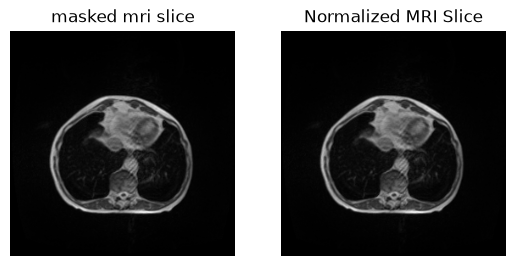

In [79]:
l, k = ds[-1]
print(l.shape)
img_norm = cv2.normalize(l[1], None, alpha=0, beta = 255, norm_type=cv2.NORM_MINMAX)
img_8 = img_norm.astype(np.uint8)
show_mask_img(img_8, k)

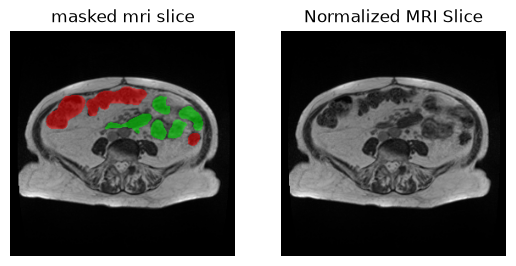

In [117]:
ds.on_epoch_end()
l, k = ds[50]
img_norm = cv2.normalize(l[1], None, alpha=0, beta = 255, norm_type=cv2.NORM_MINMAX)
img_8 = img_norm.astype(np.uint8)
show_mask_img(img_8, k)

In [ ]:

#!=================================================================================================
dev_transform = v2.Compose([
    v2.Resize(256),
    v2.CenterCrop(256),
    v2.ToDtype(dtype = torch.float32)
])


train_transform = v2.Compose([
    v2.Resize(280),
    v2.RandomCrop(256),
    v2.RandomHorizontalFlip(0.25),
    v2.RandomVerticalFlip(0.25),
    v2.RandomRotation(15),
    v2.RandomAdjustSharpness(sharpness_factor=0.8, p=0.25),
    v2.RandomAdjustSharpness(sharpness_factor=1.2, p=0.25),
    v2.ToDtype(dtype = torch.float32)
])

train_ds = MRIDataset(TRAIN_CSV, 0.2, train_transform, RANDOM_STATE)
dev_ds = MRIDataset(DEV_CSV, 0, dev_transform, RANDOM_STATE)
test_ds = MRIDataset(TEST_CSV, 0, dev_transform, RANDOM_STATE)

train_data
#!=================================================================================================


In [119]:
l, k = ds[-1]
l = tv_tensors.Image(torch.from_numpy(l))
k = tv_tensors.Mask(torch.from_numpy(k))
l, k = def_transform(l, k)
print(l.shape)

#img_norm = cv2.normalize(l[1], None, alpha=0, beta = 255, norm_type=cv2.NORM_MINMAX)
#img_8 = img_norm.astype(np.uint8)
#show_mask_img(img_8, k)


torch.Size([3, 256, 256])


In [120]:
256/310*360

297.2903225806452

In [121]:
def show_tensor_image(tensor, title=None):
    """
    Safely displays a PyTorch tensor as an image.
    Handles device placement, gradients, batch dimensions, and channel ordering.
    """
    # 1. Detach from graph (if requires_grad) and move to CPU
    tensor = tensor.detach().cpu()
    
    # 2. Handle batch dimension: If shape is (B, C, H, W), take the first image
    if tensor.ndim == 4:
        tensor = tensor[0]
        
    # 3. PyTorch uses (C, H, W), Matplotlib expects (H, W, C)
    image_np = tensor.permute(1, 2, 0).numpy()
    
    # 4. Normalize float arrays to [0, 1] for safe display
    # (Prevents clipping warnings if the tensor was normalized with negative values)
    if image_np.dtype.kind == 'f':
        image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min() + 1e-8)
        
    # 5. Display the image
    # If grayscale (H, W, 1), squeeze to (H, W) and use gray colormap
    if image_np.shape[-1] == 1:
        image_np = image_np.squeeze(-1)
        plt.imshow(image_np, cmap='gray')
    else:
        plt.imshow(image_np)
        
    if title:
        plt.title(title)
        
    plt.axis('off')
    plt.show()

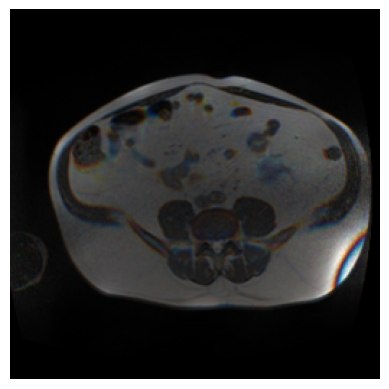

In [124]:
show_tensor_image(l)

In [ ]:
import lightning.pytorch as pl

class MRIDataModule(pl.LightningDataModule):


    def __init__(self, data_dir = './data', batch_size = 32, num_workers = 2):
        super().__init__()
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.num_workers = num_workers


        self.dev_transform = v2.Compose([
            v2.Resize(256),
            v2.CenterCrop(256),
            v2.ToDtype(dtype = torch.float32)
        ])


        self.train_transform = v2.Compose([
            v2.Resize(280),
            v2.RandomCrop(256),
            v2.RandomHorizontalFlip(0.25),
            v2.RandomVerticalFlip(0.25),
            v2.RandomRotation(15),
            v2.RandomAdjustSharpness(sharpness_factor=0.8, p=0.25),
            v2.RandomAdjustSharpness(sharpness_factor=1.2, p=0.25),
            v2.ToDtype(dtype = torch.float32)
        ])


    def setup(self, stage = None):
        
        self.train_ds = MRIDataset(TRAIN_CSV, 0.2, self.train_transform, RANDOM_STATE)
        self.dev_ds = MRIDataset(DEV_CSV, 1, self.dev_transform, RANDOM_STATE)
        self.test_ds = MRIDataset(TEST_CSV, 1, self.dev_transform, RANDOM_STATE)


    def train_dataloader(self):
        return DataLoader(self.train_ds, self.batch_size, shuffle = True, num_workers=self.num_workers)

    def val_dataloader(self):
        return DataLoader(self.train_ds, self.batch_size, shuffle = False, num_workers=self.num_workers)
    
    def test_dataloader(self):
        return DataLoader(self.train_ds, self.batch_size, shuffle = False, num_workers=self.num_workers)

    

In [16]:
import torch.nn as nn

In [ ]:
class MRIFlexModel(nn.Module):
    def __init__(self, )
        nn.

In [17]:
import torch.functional as F 

In [22]:
class ConvBlock(nn.Module):



    def __init__(self, in_channels: int, n_layers: int, n_filters: list, kernel_sizes: list):

        super().__init__()

        blocks = []
        

        for i in range(n_layers):
        
            padding = (kernel_sizes[i] - 1)//2

            block = nn.Sequential(
                nn.Conv2d(in_channels, n_filters[i], kernel_sizes[i], padding = padding),
                nn.BatchNorm2d(n_filters[i]),
                nn.ReLU()
            )

            blocks.append(block)

            in_channels = n_filters[i]


        self.conv_block = nn.Sequential(*blocks)



    def forward(self, x):

        return self.conv_block(x)


        



In [23]:
class EncoderBlock(nn.Module):



    def __init__(self, in_channels: int, n_layers: int, n_filters: list, kernel_sizes: list):

        super().__init__()

        
        self.conv_block = ConvBlock(in_channels, n_layers, n_filters, kernel_sizes)
        self.pool = nn.MaxPool2d(2,2)



    def forward(self, x):

        skip = self.conv_block(x)

        out = self.pool(skip)
        return skip, out


        



        

In [ ]:
class AttentionGate(nn.Module):



    def __init__(self, inp_channels, s_channels, out_channels):

        super().__init__()

        self.Wg = nn.Sequential(
            nn.Conv2d(inp_channels, out_channels, kernel_size=1),
            nn.BatchNorm2d(out_channels)
        )
        self.Ws = nn.Sequential(
            nn.Conv2d(s_channels, out_channels, kernel_size=1),
            nn.BatchNorm2d(out_channels)
        )
        self.atten = nn.Sequential(
            nn.Conv2d(out_channels, 1, kernel_size=1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU()


    def forward(self, inp, skip):
        g = self.Wg(inp)       
        s = self.Ws(skip)       
        out = self.relu(g+s)
        attention = self.atten(out)   
        return s * attention        

3

In [25]:
class DecoderBlock(nn.Module):
    def __init__(self,  in_channels: int, skip_channels: int, n_layers: int, n_filters: list, kernel_sizes: list):
        super().__init__()

        self.conv = ConvBlock(in_channels, n_layers, n_filters, kernel_sizes)
        self.upsample = nn.Upsample(size = in_channels, scale_factor=2, mode = 'bilinear', align_corners= False)
        self.attention = AttentionGate(in_channels, skip_channels, n_filters[-1])


    def forward(self, x , skip):
        x = self.upsample(x)
        out= self.attention(x, skip)

        out = torch.cat([out, x], dim = 1)
        

        return self.conv(out)




In [27]:
lia = [1,2,3,4,5]
lia.reverse()
lia

[5, 4, 3, 2, 1]